# 📘Student Notebook: Predictive Maintenance for CNC Machine Systems

Predictive maintenance uses data from sensors, such as vibration, temperature, and pressure sensors, to monitor the condition of equipment. AI algorithms can analyze this data to detect patterns and anomalies that indicate when equipment is likely to fail. By identifying potential problems early, manufacturers can schedule maintenance at a convenient time, avoiding unexpected downtime. This can help to reduce maintenance costs and increase the lifespan of equipment. In addition, predictive maintenance can also help to improve safety by identifying and addressing potential hazards before they occur.

We are using machine data (temperature, torque, speed) to predict if a motor will fail

Map to Real Manufacturing
-  Feature  	   -         Meaning
-  Temperature	   -         Overheating risk
-  Torque	       -         Load on machine
-  Speed	       -         Operating condition
-  Tool wear	   -         Maintenance need
-  Target	       -         Failure (1) or Not (0)

## 0.1 Import Libraries

In [1]:
!pip install xgboost

# Data handling
import pandas as pd
import numpy as np

# Visualization (optional)
import matplotlib.pyplot as plt

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler #Put everything on the same measurement scale
from sklearn.metrics import accuracy_score     #Percentage of correct predictions the AI makes, i.e. Accuracy = 4/5 = 0.80 = 80%

import xgboost as xgb                          #Fast, Accurate, Handles large datasets

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")


## 0.2 Load Dataset

In [2]:
# Load dataset
data = pd.read_csv("./data8_PM/predictive_maintenance.csv")

# View first rows
data.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


## 0.3 Understand the Data

In [3]:
# Basic info
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Target                   10000 non-null  int64  
 9   Failure Type             10000 non-null  object 
dtypes: float64(3), int64(4), object(3)
memory usage: 781.4+ KB


In [40]:
# Summary statistics
data.describe() 

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000


In [4]:
# Check missing values
data.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Target                     0
Failure Type               0
dtype: int64

## 0.4 Define Features and Target

In [5]:
# Example: adjust based on your dataset columns
# Common predictive maintenance dataset uses "Failure Type" or "Target"

# Drop unnecessary columns if needed
data = data.drop(['UDI', 'Product ID'], axis=1)

# Target column, What we want to predict                (adjust if needed)
y = data['Target']   # y=Target column only   or you can use Failure Type

# Features, Inputs used to make predictions
X = data.drop(['Target', 'Failure Type'], axis=1)                #We remove the target column from the input data because we don’t want the model to cheat. The model should only use the other features to predict the target

## 0.5 Convert Categorical Data

Example of converting categorical text
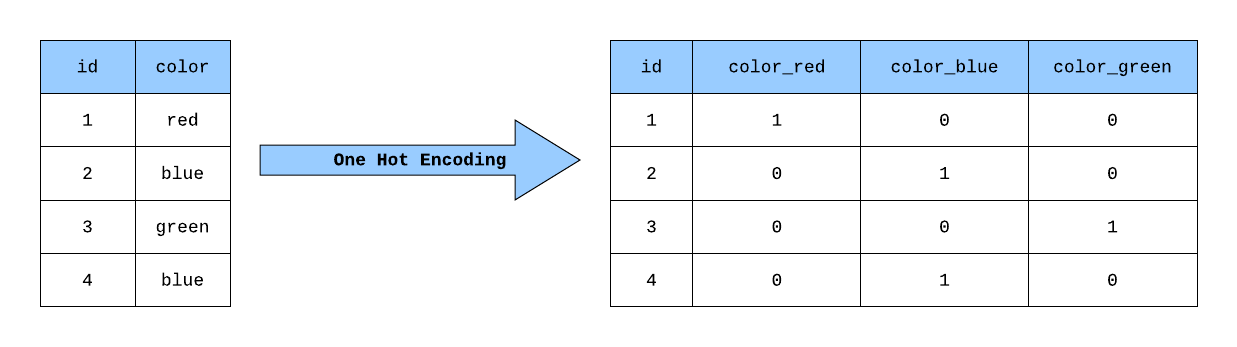![image.png]

In [6]:
# Convert categorical columns to binary columns so model can use them, i.e. Type
X = pd.get_dummies(X, drop_first=True)   #get_dummies() converts categorical text into 0/1 columns, and drop_first=True avoids duplicate information.

In [7]:
X.head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Type_L,Type_M
0,298.1,308.6,1551,42.8,0,0,1
1,298.2,308.7,1408,46.3,3,1,0
2,298.1,308.5,1498,49.4,5,1,0
3,298.2,308.6,1433,39.5,7,1,0
4,298.2,308.7,1408,40.0,9,1,0


## 0.6 Train-Test Split

In [8]:
#Splits data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42)               #Splitting Rows of data, Training Data 75%, Testing Data (25%)
     #Before: y = [0, 1, 0, 0, 1]   After:y_train = [0, 1, 0], y_test  = [0, 1]

## 0.7 Scale the Data

Scaling puts all features on the same level so no single feature dominates the model

-  Feature	Example Values
-  Temperature	300–350
-  Torque	10–50
-  Speed	1000–3000

In [9]:
#learns how to scale the data and then applies that scaling
scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
#We scale data so large numbers don’t dominate—and we handle outliers

## 0.8 Train Model (XGBoost)

In [10]:
#Creates XGBoost classification model (ML algorithm that uses decision trees)
model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')
#use_label_encoder=False, Turns off an older feature (not needed anymore)
#eval_metric='logloss', This is how the model measures error during training, Lower logloss = better model


In [11]:
#Trains Model
model.fit(X_train_scaled, y_train)            #binary:logistic  = turns 0 & 1, 1s to Percentage

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=None, ...)

## 0.9 Make Predictions

In [12]:
y_pred = model.predict(X_test_scaled)

## 0.10 Evaluate Model

In [13]:
accuracy = accuracy_score(y_test, y_pred)     #y_test = real answers, y_pred = model predictions

print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 98.56%


## 0.11 Feature Importance

In [14]:
importances = model.feature_importances_

feature_names = X.columns

# Create dataframe
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

importance_df.head(10)

,Feature,Importance
3,Torque [Nm],0.246969
2,Rotational speed [rpm],0.164289
4,Tool wear [min],0.156862
0,Air temperature [K],0.154449
1,Process temperature [K],0.118913
5,Type_L,0.109165
6,Type_M,0.049353


## 0.12 Visualize Importance

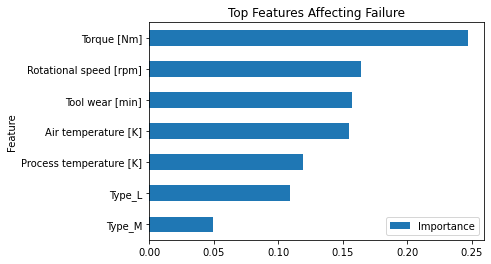

In [15]:
importance_df.head(10).plot(
    kind='barh',
    x='Feature',
    y='Importance'
)

plt.title("Top Features Affecting Failure")
plt.gca().invert_yaxis()
plt.show()